# Analizando clientes de aseguradora

# Contenido <a id='back'></a>

* [1. Introducción](#intro)
* [2. Preprocesamiento y exploración de datos](#preprocessing)
* [3. Análisis Exploratorio de Datos](#eda)
* [4. Clientes similares](#similar_clients)
* [5. Prestación del seguro](#assurance)
* [6. Modelo de regresion lineal](#linear_regression)
* [7. Ofuscar datos](#mask_data)
    * [7.1 Prueba de que la ofuscación de datos puede funcionar con regresión lineal](#proof)
* [8. Modelo de regresión lineal con ofuscación de datos](#mask_model)
* [Conclusiones](#end)
* [Apéndices](#apendices)
  

## Introducción <a id='intro'></a>

La compañía de seguros Sure Tomorrow quiere resolver varias tareas con la ayuda de machine learning. El proyecto consiste en evaluar lo siguiente:
- 1. Encontrar clientes que sean similares a un cliente determinado. Esto ayudará a los agentes de la compañía con el marketing.
- 2. Predecir la probabilidad de que un nuevo cliente reciba una prestación del seguro. 
- 3. Predecir el número de prestaciones de seguro que un nuevo cliente pueda recibir utilizando un modelo de regresión lineal.
- 4. Proteger los datos personales de los clientes sin afectar al modelo del ejercicio anterior. Es necesario desarrollar un algoritmo de transformación de datos que dificulte la recuperación de la información personal si los datos caen en manos equivocadas. Tambien llamado enmascaramiento u ofuscación de datos. Los datos se protegen de tal manera que no se ve afectada la calidad de los modelos de machine learning. 


## Preprocesamiento y exploración de datos <a id='preprocessing'></a>

In [1]:
pip install scikit-learn --upgrade

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.2 MB 18.1 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.2 MB 22.4 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 14.7 MB/s  0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.2
    Uninstalling scikit-learn-1.7.2:
      Successfully uninstalled scikit-learn-1.7.2
Note: you may need to restart the kernel to use updated packages.


In [10]:
import numpy as np
import pandas as pd

import seaborn as sns

import sklearn.linear_model
import sklearn.metrics
import sklearn.neighbors
import sklearn.preprocessing

from sklearn.model_selection import train_test_split

from IPython.display import display
import math
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [11]:
#lectura de los datos
df = pd.read_csv('insurance_us.csv')

In [12]:
#Renombramos las columnas para que el código se vea más coherente con su estilo.
df = df.rename(columns={'Gender': 'gender', 'Age': 'age', 'Salary': 'income', 'Family members': 'family_members', 'Insurance benefits': 'insurance_benefits'})

In [13]:
df.sample(10) #vizualizar primeras filas

,gender,age,income,family_members,insurance_benefits
4621,0,22.0,20800.0,1,0
627,1,24.0,56100.0,2,0
1733,1,35.0,38300.0,0,0
3262,1,20.0,41200.0,0,0
4286,0,27.0,27500.0,1,0
4774,0,31.0,32800.0,1,0
4890,1,32.0,46300.0,1,0
4024,1,39.0,35500.0,0,0
1700,0,37.0,30900.0,1,0
3920,0,40.0,38000.0,0,0


In [14]:
df.info() #imprime info del dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              5000 non-null   int64  
 1   age                 5000 non-null   float64
 2   income              5000 non-null   float64
 3   family_members      5000 non-null   int64  
 4   insurance_benefits  5000 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 195.4 KB


In [15]:
#cambiar el tipo de edad (de float a int) 
df['age']=df['age'].astype('int')

In [16]:
# compruebación que la conversión se haya realizado con éxito
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              5000 non-null   int64  
 1   age                 5000 non-null   int64  
 2   income              5000 non-null   float64
 3   family_members      5000 non-null   int64  
 4   insurance_benefits  5000 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 195.4 KB


In [17]:
#Observación de las estadísticas descriptivas de los datos
df.describe()

,gender,age,income,family_members,insurance_benefits
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.499000,30.952800,39916.360000,1.194200,0.148000
std,0.500049,8.440807,9900.083569,1.091387,0.463183
min,0.000000,18.000000,5300.000000,0.000000,0.000000
25%,0.000000,24.000000,33300.000000,0.000000,0.000000
50%,0.000000,30.000000,40200.000000,1.000000,0.000000
75%,1.000000,37.000000,46600.000000,2.000000,0.000000
max,1.000000,65.000000,79000.000000,6.000000,5.000000


Los datos tienen valores coherentes, no tenemos ausentes ni atipicos o extremos.

## Análisis exploratorio de datos <a id='eda'></a>

Vamos a comprobar rápidamente si existen determinados grupos de clientes observando el gráfico de pares.

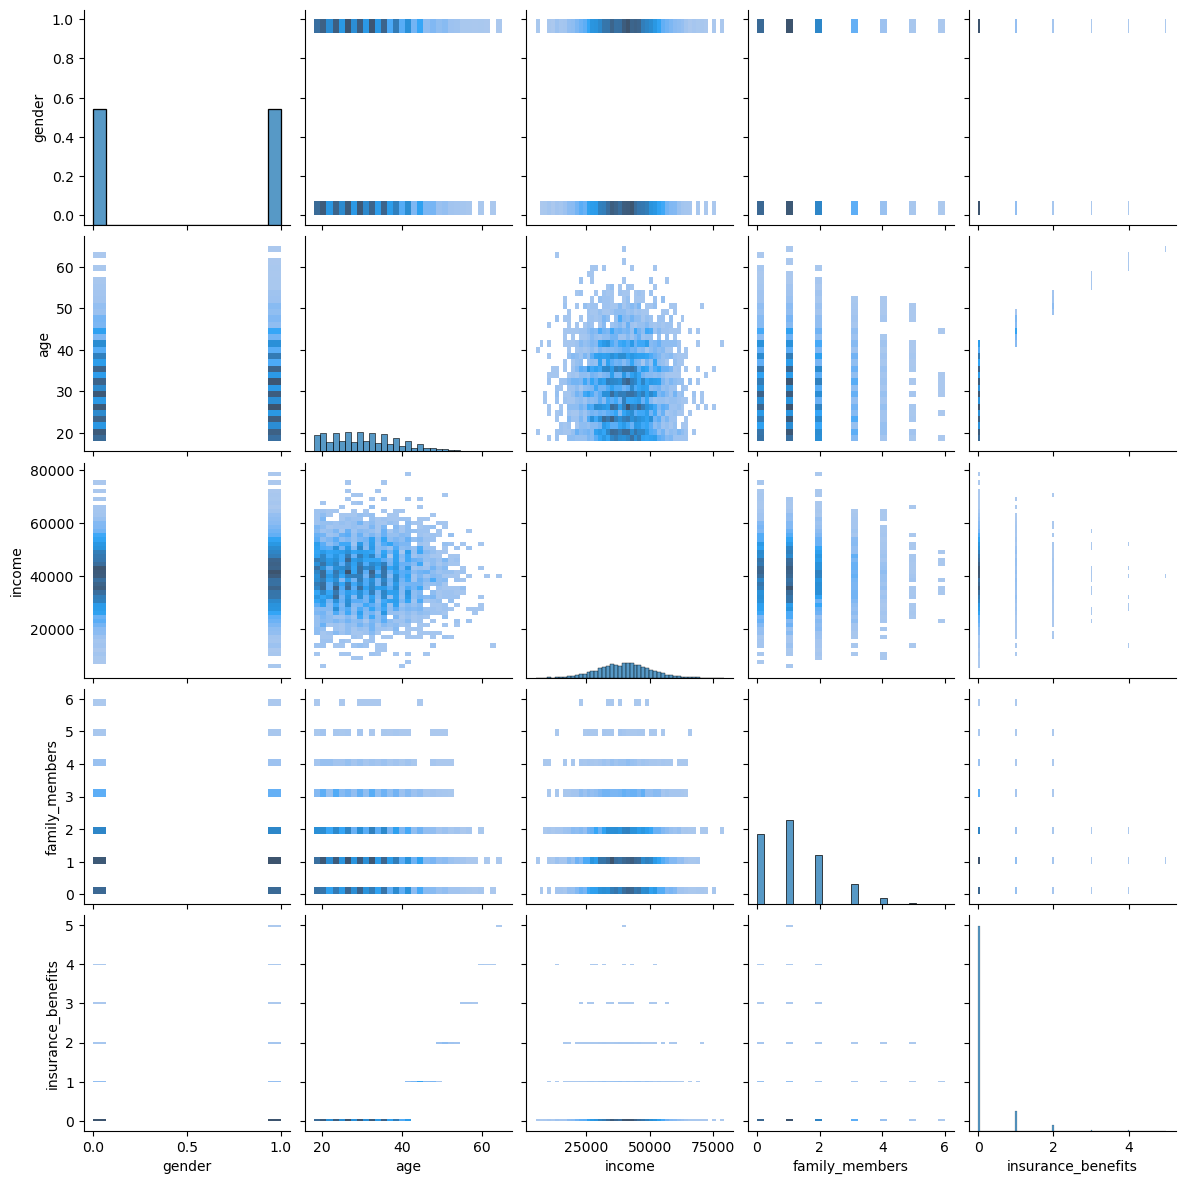

In [18]:
g = sns.pairplot(df, kind='hist') # Se genera una cuadrícula de gráficos (pairplot) para analizar las relaciones bidimensionales entre todas las variables numéricas del DataFrame en un histograma
g.fig.set_size_inches(12, 12) #figura subyacente de matplotlib para ajustar las dimensiones totales del gráfico a un tamaño cuadrado de 12 por 12 pulgadas.

Se pueden observa que algunos parametros tienen una relacion clara entre ellos, como por ejemplo los beneficios de los seguros que van aumentando conforme a la edad a partir de los 40. Debido a que es dificil combinar simultaneamente multiples parametros para detectar grupos obvios o clústeres para analizar distribuciones multivariadas, es bastante útil recurrir al algebra lineal y machine learning (ML).

## Clientes similares <a id='similar_clients'></a>

En el lenguaje de ML, se desarrolla un procedimiento que devuelva los k vecinos más cercanos (objetos) para un objeto dado basándose en la distancia entre los objetos. 
- Distancia entre vectores -> Distancia Manhattan
  
Se prueban diferentes métricas de distancia.

Se escribe una función que devuelve los k vecinos más cercanos para un $n^{th}$ objeto basándose en una métrica de distancia especificada. En esta función no se toma en cuenta el número de prestaciones de seguro recibidas.

Se prueba para cuatro combinaciones de dos casos:
  - los datos no están escalados
  - los datos se escalan con el escalador MaxAbsScaler

Métricas de distancia
  - Euclidiana
  - Manhattan


In [19]:
#definimos las caracteristicas
feature_names = ['gender', 'age', 'income', 'family_members']

In [20]:
# funcion que devuelve los k vecinos mas cercanos
def get_knn(df, n, k, metric):
    
    """
    Devuelve los k vecinos más cercanos

    :param df: DataFrame de pandas utilizado para encontrar objetos similares dentro del mismo lugar    
    :param n: número de objetos para los que se buscan los vecinos más cercanos    
    :param k: número de vecinos más cercanos a devolver
    :param métrica: nombre de la métrica de distancia    """

    
    # Se inicializa y entrena el modelo NearestNeighbors con el número de vecinos (k) y la métrica deseada.
    # El entrenamiento (.fit) se realiza utilizando únicamente las columnas especificadas en 'feature_names'.
    nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=k, metric=metric).fit(df[feature_names])
    # Se calculan las distancias e índices de los 'k' vecinos más cercanos para el objeto ubicado en la fila 'n'.
    # Se extraen las características de la fila 'n' usando df.iloc[n][feature_names] y se pasan como una lista de un solo elemento.
    nbrs_distances, nbrs_indices = nbrs.kneighbors([df.iloc[n][feature_names]], k, return_distance=True)
    
    df_res = pd.concat([
        df.iloc[nbrs_indices[0]], 
        pd.DataFrame(nbrs_distances.T, index=nbrs_indices[0], columns=['distance'])
        ], axis=1)
    
    return df_res

In [21]:
#Proceso de escalado de datos

feature_names = ['gender', 'age', 'income', 'family_members']

transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(df[feature_names].to_numpy())

df_scaled = df.copy()
df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())

C:\Users\Administrator\AppData\Local\Temp\ipykernel_6372\3087733256.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.63076923 0.70769231 0.44615385 ... 0.30769231 0.33846154 0.43076923]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6372\3087733256.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.16666667 0.16666667 0.         ... 0.33333333 0.5        0.16666667]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())


In [22]:
df_scaled.sample(5)

,gender,age,income,family_members,insurance_benefits
4355,0,0.338462,0.517722,0.000000,0
3573,1,0.461538,0.453165,0.166667,0
2061,0,0.400000,0.627848,0.166667,0
711,1,0.723077,0.464557,0.166667,1
3409,1,0.584615,0.393671,0.166667,0


Ahora, vamos a obtener registros similares para uno determinado, para cada combinación

In [23]:
k=5
n= len(df_scaled) - 1 

In [24]:
for datos, metrica in [[df, 'euclidean'], [df_scaled, 'euclidean'], [df, 'manhattan'], [df_scaled, 'manhattan']]:
    if datos is not df_scaled:
        es_escalado=False
    else:
        es_escalado= True

    print(f'metric={metrica}, escalado={es_escalado}')
    
    vecinos_cercanos=get_knn(datos,n,k, metrica)
    
    if es_escalado:
        vecinos_cervcanos=pd.concat([df.loc[vecinos_cercanos.index], vecinos_cercanos], axis=1, keys=['original', 'escalado'])
        
    print(vecinos_cercanos)

metric=euclidean, escalado=False
      gender  age   income  family_members  insurance_benefits  distance
4999       1   28  40600.0               1                   0  0.000000
3512       1   27  40600.0               1                   0  1.000000
4284       1   25  40600.0               1                   0  3.000000
296        1   26  40600.0               4                   0  3.605551
3964       1   24  40600.0               1                   0  4.000000
metric=euclidean, escalado=True
      gender       age    income  family_members  insurance_benefits  distance
4999       1  0.430769  0.513924        0.166667                   0  0.000000
4989       1  0.430769  0.517722        0.166667                   0  0.003797
2813       1  0.430769  0.498734        0.166667                   0  0.015190
3512       1  0.415385  0.513924        0.166667                   0  0.015385
4167       1  0.415385  0.515190        0.166667                   0  0.015437
metric=manhattan, escal

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


**¿El hecho de que los datos no estén escalados afecta al algoritmo kNN? Si es así, ¿cómo se manifiesta?** 

Sí, en caso de que los datos no esten escalados, habra variables que tengan mayor peso que otras lo que hara que la predicción este mas inclunada a los parametros de mayor valor, he aqui la importancia de escalar los datos para mayor precision del algoritmo.

**¿Qué tan similares son los resultados al utilizar la métrica de distancia Manhattan (independientemente del escalado)?** 

Aun cuando los datos no estan escalados, las distancias euclidiana y manhattan son similares, lo que nos indica que las dimensiones son casi equivalentes en escala y contribución, así como que las coordenadas de los puntos estan cercanos entre sí. Es probable que ambas metricas tanto nearest neighbors y regresión basada en distancia funciones de forma similar, tambien implica que los datos estan bien preparados sin outliers extremos.

## Prestación del seguro <a id='assurance'></a>

En términos de machine learning podemos considerarlo como una tarea de clasificación binaria, donde se otorga o no el prestamo del seguro, unicamente dos valores posibles. 

Con el valor de `insurance_benefits` superior a cero como objetivo, evalúa si el enfoque de clasificación kNN puede funcionar mejor que el modelo dummy.
A continuación:
- Se construye un clasificador basado en KNN y se mide su calidad con la métrica F1 para k=1...10 tanto para los datos originales como para los escalados. Se observa cómo k puede influir en la métrica de evaluación y si el escalado de los datos provoca alguna diferencia.
- Se construye un modelo dummy que, en este caso, es simplemente un modelo aleatorio. Debería devolver "1" con cierta probabilidad. Probemos el modelo con cuatro valores de probabilidad: 0, la probabilidad de pagar cualquier prestación del seguro, 0.5, 1.
La probabilidad de pagar cualquier prestación del seguro puede definirse como
$$
P\{\text{prestación de seguro recibida}\}=\frac{\text{número de clientes que han recibido alguna prestación de seguro}}{\text{número total de clientes}}.
$$

Se divinen todos los datos correspondientes a las etapas de entrenamiento/prueba respetando la proporción 70:30.

In [25]:
# сalcula el objetivo
df['insurance_benefits_received'] = (df['insurance_benefits'] > 0).astype('int') 

In [26]:
# comprueba el desequilibrio de clases con value_counts()
df['insurance_benefits_received'].value_counts()

insurance_benefits_received
0    4436
1     564
Name: count, dtype: int64

In [27]:
#funcion evaluacion de clasificadores
def eval_classifier(y_true, y_pred):
    """
    Calcula e imprime las métricas de rendimiento F1-Score y la Matriz de Confusión.
    
    :param y_true: Valores reales/verdaderos del conjunto de datos.
    :param y_pred: Valores predichos por el modelo de clasificación.
    """
    
    # Se calcula la métrica F1-score (media armónica entre precisión y exhaustividad)
    f1_score = sklearn.metrics.f1_score(y_true, y_pred)
    print(f'F1: {f1_score:.2f}')
    
    # Se calcula la matriz de confusión normalizando todos los valores entre 0 y 1 (normalize='all')
    # Esto transforma los conteos absolutos en porcentajes/proporciones sobre el total de datos.   
    cm = sklearn.metrics.confusion_matrix(y_true, y_pred, normalize='all')
    # Se muestran los encabezados y la matriz resultante en la consola
    print('Matriz de confusión')
    print(cm)

In [28]:
# generar la salida de un modelo aleatorio
#MODELO DE PREDICCIÓN ALEATORIA BASADO EN DISTRIBUCIÓN BINOMIAL


def rnd_model_predict(P, size, seed=42):
    """
    Genera predicciones aleatorias binarias (0 o 1) simulando un modelo base (baseline).
    
    :param P: Probabilidad de éxito (clase 1) para cada intento.
    :param size: Cantidad de datos o predicciones a generar (forma/tamaño del arreglo).
    :param seed: Semilla aleatoria para garantizar la reproducibilidad de los resultados.
    """

    # Se inicializa el generador de números aleatorios moderno de NumPy (PCG64) 
    # utilizando una semilla (seed) para que la secuencia de azar sea siempre idéntica.

    rng = np.random.default_rng(seed=seed)
    # Se simula un experimento binomial con n=1 (un solo intento por registro, equivalente a Bernoulli).
    # Genera un arreglo de ceros y unos donde la probabilidad de obtener '1' es exactamente P.
    return rng.binomial(n=1, p=P, size=size)

In [29]:
# EVALUACIÓN DE MODELOS ALEATORIOS CON DIFERENTES PROBABILIDADES (BASELINES)
# Se inicia un bucle 'for' para probar cuatro escenarios de probabilidad (P) distintos:
# 1. P = 0: El modelo predice que NADIE recibe beneficios (siempre predice 0).
# 2. P = proporción real: La probabilidad coincide exactamente con el porcentaje real de clientes que cobraron seguro.
# 3. P = 0.5: El modelo lanza una moneda equilibrada (50% de probabilidad para 0 y 1).
# 4. P = 1: El modelo predice que TODOS reciben beneficios (siempre predice 1).
for P in [0, df['insurance_benefits_received'].sum() / len(df), 0.5, 1]:

    # Se imprime en pantalla la probabilidad actual formateada a 2 decimales (:2f)
    print(f'La probabilidad: {P:.2f}')

    # Se generan las predicciones aleatorias (ceros y unos) llamando a la función previa,
    # asegurando que el tamaño del arreglo coincida con el total de filas del DataFrame.
    y_pred_rnd = rnd_model_predict(P,size=len(df)) 

    # Se evalúa el desempeño de esta simulación comparando los valores reales 
    # de la columna 'insurance_benefits_received' contra las predicciones del azar (y_pred_rnd).
    # Esto imprimirá el F1-Score y la Matriz de Confusión para cada escenario.
    eval_classifier(df['insurance_benefits_received'], y_pred_rnd)
    
    print()

La probabilidad: 0.00
F1: 0.00
Matriz de confusión
[[0.8872 0.    ]
 [0.1128 0.    ]]

La probabilidad: 0.11
F1: 0.12
Matriz de confusión
[[0.7914 0.0958]
 [0.0994 0.0134]]

La probabilidad: 0.50
F1: 0.20
Matriz de confusión
[[0.456  0.4312]
 [0.053  0.0598]]

La probabilidad: 1.00
F1: 0.20
Matriz de confusión
[[0.     0.8872]
 [0.     0.1128]]



In [30]:
# SEPARACIÓN DE CARACTERÍSTICAS (X) Y VARIABLE OBJETIVO (y)

# Se seleccionan las columnas de características (variables independientes): 'age', 'gender', 'income' y 'family_members'.
# Con '.to_numpy()' se convierte esta sección del DataFrame de Pandas en una matriz bidimensional (Array) de NumPy.
X= df[['age', 'gender', 'income', 'family_members']].to_numpy()

# Se selecciona la columna objetivo (variable dependiente): 'insurance_benefits_received'.
# Con '.to_numpy()' se convierte esta serie en un arreglo unidimensional (Vector) de NumPy.
y=df['insurance_benefits_received'].to_numpy()

In [32]:
# DIVISIÓN DEL CONJUNTO DE DATOS (ENTRENAMIENTO Y PRUEBA)
x_train, x_test, y_train, y_test=train_test_split(X,y, test_size=0.3)

num vecinos_1
F1: 0.64
Matriz de confusión
[[0.85533333 0.02733333]
 [0.05       0.06733333]]

num vecinos_2
F1: 0.36
Matriz de confusión
[[0.874      0.00866667]
 [0.09       0.02733333]]

num vecinos_3
F1: 0.36
Matriz de confusión
[[0.86266667 0.02      ]
 [0.08733333 0.03      ]]

num vecinos_4
F1: 0.13
Matriz de confusión
[[0.87666667 0.006     ]
 [0.10866667 0.00866667]]

num vecinos_5
F1: 0.14
Matriz de confusión
[[0.87533333 0.00733333]
 [0.108      0.00933333]]

num vecinos_6
F1: 0.09
Matriz de confusión
[[0.88       0.00266667]
 [0.112      0.00533333]]

num vecinos_7
F1: 0.08
Matriz de confusión
[[0.878      0.00466667]
 [0.112      0.00533333]]

num vecinos_8
F1: 0.03
Matriz de confusión
[[0.88266667 0.        ]
 [0.11533333 0.002     ]]

num vecinos_9
F1: 0.04
Matriz de confusión
[[0.88266667 0.        ]
 [0.11466667 0.00266667]]

num vecinos_10
F1: 0.02
Matriz de confusión
[[0.88266667 0.        ]
 [0.116      0.00133333]]



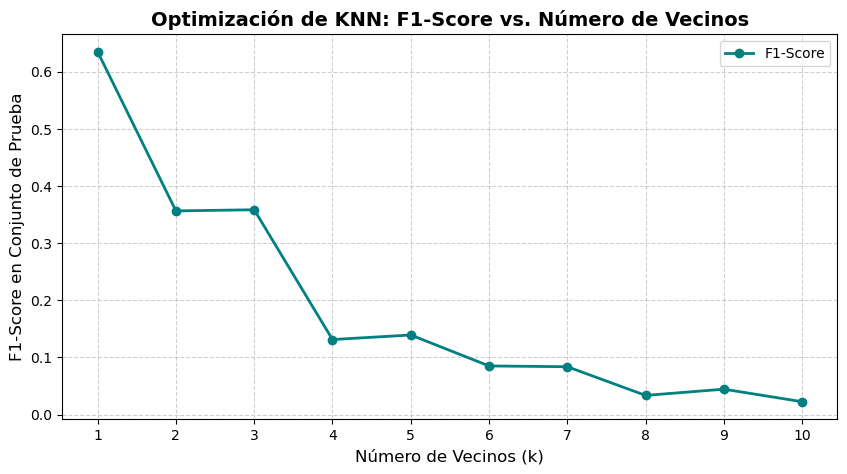

In [34]:
import matplotlib.pyplot as plt
import sklearn.metrics

# Listas vacías para almacenar los datos que vamos a graficar
lista_vecinos = []
lista_f1 = []

# BUCLE DE OPTIMIZACIÓN MODIFICADO PARA GUARDAR LAS MÉTRICAS
for num_vecinos in range(1, 11):
    print(f'num vecinos_{num_vecinos}')
    
    # Configurar y entrenar el modelo KNN
    vecinos = sklearn.neighbors.KNeighborsClassifier(n_neighbors=num_vecinos)
    vecinos.fit(x_train, y_train)
    
    # Generar predicciones en el conjunto de prueba
    y_test_pred = vecinos.predict(x_test)
    
    # Calcular el F1-Score numérico actual
    f1_actual = sklearn.metrics.f1_score(y_test, y_test_pred)
    
    # GUARDAR LOS DATOS: Guardamos el número de vecinos y su respectivo F1
    lista_vecinos.append(num_vecinos)
    lista_f1.append(f1_actual)
    
    # Evaluar con tu función original
    eval_classifier(y_test, y_test_pred)
    print()

# ==============================================================================
# CREACIÓN DE LA GRÁFICA DE RENDIMIENTO (F1 VS. NÚMERO DE VECINOS)
# ==============================================================================
plt.figure(figsize=(10, 5))

# Graficar la línea de rendimiento con marcadores en cada punto
plt.plot(lista_vecinos, lista_f1, marker='o', linestyle='-', color='teal', linewidth=2, label='F1-Score')
# Configuración de etiquetas y títulos
plt.title('Optimización de KNN: F1-Score vs. Número de Vecinos', fontsize=14, fontweight='bold')
plt.xlabel('Número de Vecinos (k)', fontsize=12)
plt.ylabel('F1-Score en Conjunto de Prueba', fontsize=12)

# Configurar el eje X para que muestre exactamente los números del 1 al 10
plt.xticks(lista_vecinos)

# Agregar una cuadrícula de fondo para facilitar la lectura visual
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Mostrar la gráfica en el Jupyter Notebook
plt.show()

El mejor rendimiento aparente del modelo se obtiene estrictamente con k = 1 vecino, alcanzando su punto máximo con un F1-Score aproximado de 0.63. En el algoritmo KNN, un rendimiento inusualmente alto únicamente cuando k=1 suele ser un síntoma de sobreajuste (overfitting). El modelo es capaz de identificar la similitud perfecta cuando se compara contra un solo vecino idéntico o muy cercano, pero pierde toda su capacidad de generalizar cuando se le pide analizar un entorno más amplio.
Esto se confirma cuando con k=2 vecinos la predicción se vuelve sumamente inestable en cuanto el algoritmo tiene que promediar la información de más de una persona y el F1 cae a 0.37 aproximadamente.
A partir de 4 vecinos en adelante, el rendimiento cae a niveles alarmantes (por debajo de 0.15), llegando casi a cero en k=10. Un F1-Score tan bajo significa que el modelo es estadísticamente inútil para el negocio de seguros en esas condiciones, ya que está fallando masivamente en encontrar a los clientes que reciben beneficios.


## Modelo de regresión lineal <a id='linear_regression'></a>

Con `insurance_benefits` como objetivo, se evalúa cuál sería la RECM de un modelo de regresión lineal.

Se denotemos- $X$: matriz de características; cada fila es un caso, cada columna es una característica, la primera columna está formada por unidades- $y$ — objetivo (un vector)- $\hat{y}$ — objetivo estimado (un vector)- $w$ — vector de pesos
La tarea de regresión lineal en el lenguaje de las matrices puede formularse así:
$$
y = Xw
$$

El objetivo de entrenamiento es entonces encontrar esa $w$ w que minimice la distancia L2 (ECM) entre $Xw$ y $y$:

$$
\min_w d_2(Xw, y) \quad \text{or} \quad \min_w \text{MSE}(Xw, y)
$$

Parece que hay una solución analítica para lo anteriormente expuesto:
$$
w = (X^T X)^{-1} X^T y
$$

La fórmula anterior puede servir para encontrar los pesos $w$ y estos últimos pueden utilizarse para calcular los valores predichos
$$
\hat{y} = X_{val}w
$$

Se divide todos los datos correspondientes a las etapas de entrenamiento/prueba respetando la proporción 70:30. Utiliza la métrica RECM para evaluar el modelo.

In [35]:
# CLASE PERSONALIZADA DE REGRESIÓN LINEAL (MÉTODO MATRICIAL)
# Este bloque implementa un modelo propio de Regresión Lineal desde cero utilizando la Ecuación Normal (álgebra lineal matricial) en lugar de librerías como scikit-learn:

class MyLinearRegression:
    
    def __init__(self):
        # Se inicializan los pesos (coeficientes) del modelo como None.
        # Estos pesos se calcularán matemáticamente durante la fase de entrenamiento (fit).
        self.weights = None
    
    def fit(self, X, y):
        # 1. Se añade una columna de unos (1) a la izquierda de la matriz de características X.
        # Esto representa analíticamente el término de intersección o sesgo (bias / intercepto b).
        # añadir las unidades
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        # 2. Se calcula el vector de pesos óptimo aplicando la fórmula de la Ecuación Normal:
        # w = (X^T * X)^(-1) * X^T * y
        # Se utiliza el operador '@' para la multiplicación de matrices y 'np.linalg.inv' para la inversa.
        self.weights = np.linalg.inv(X2.T@ X2) @ X2.T @ y 

    def predict(self, X):
        # 1. Se añade nuevamente la columna de unos (1) a la matriz X de prueba 
        # para que coincida en dimensiones con la matriz de entrenamiento y el intercepto.
        # añadir las unidades
        X2 = np.append(np.ones([len(X),1]),X,axis=1) 
        # 2. Se generan las predicciones multiplicando de forma matricial las características por los pesos.
        # Fórmula: y_pred = X2 * w
        y_pred = X2@ self.weights 
        
        return y_pred

In [36]:
# FUNCIÓN DE EVALUACIÓN DE MODELOS DE REGRESIÓN
def eval_regressor(y_true, y_pred):
    """
    Calcula e imprime las métricas RMSE (Error Cuadrático Medio) y el Coeficiente R2.
    
    :param y_true: Valores reales o verdaderos del conjunto de datos.
    :param y_pred: Valores numéricos predichos por el modelo de regresión.
    """
    
    # 1. Se calcula el Error Cuadrático Medio (MSE) con scikit-learn y se le aplica 
    # la raíz cuadrada (math.sqrt) para obtener el RMSE. Esto devuelve el error 
    # promedio directo en la escala y unidad original de tus datos.
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    print(f'RMSE: {rmse:.2f}')

    # 2. Corrección de interpretación técnica: 
    # El coeficiente de determinación R² (r2_score) ya mide la varianza explicada.
    # Nota: Aplicarle una raíz cuadrada a un R² no es el estándar común (lo convertiría en el coeficiente de correlación R),
    # pero el código calcula esta métrica y la guarda en la variable 'r2_score'.
    r2_score = math.sqrt(sklearn.metrics.r2_score(y_true, y_pred))
    print(f'R2: {r2_score:.2f}')    

In [37]:
# PIPELINE COMPLETO DE REGRESIÓN LINEAL PERSONALIZADA (MYLINEARREGRESSION)
# 1. PREPARACIÓN DE DATOS (ÁLGEBRA LINEAL)
# Se extraen las características del DataFrame y se convierten en una matriz bidimensional de NumPy
X = df[['age', 'gender', 'income', 'family_members']].to_numpy()
# Se extrae la columna objetivo ('insurance_benefits') y se convierte en un vector unidimensional de NumPy
y = df['insurance_benefits'].to_numpy()

# 2. DIVISIÓN DEL CONJUNTO DE DATOS
# Se dividen los datos en entrenamiento (70%) y prueba (30%).
# Se usa random_state=12345 para garantizar que la división sea exactamente igual en cada ejecución.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

# 3. INSTANCIACIÓN DEL MODELO
# Se crea un objeto 'lr' a partir de la clase personalizada MyLinearRegression
lr = MyLinearRegression()

# 4. ENTRENAMIENTO DEL ALGORITMO
# Se ejecuta la Ecuación Normal para calcular los pesos óptimos con el set de entrenamiento
lr.fit(X_train, y_train)
print(lr.weights)

# 5. PREDICCIÓN Y EVALUACIÓN
# El modelo realiza las predicciones de beneficios de seguro utilizando los datos de prueba (X_test)
y_test_pred = lr.predict(X_test)
eval_regressor(y_test, y_test_pred)

[-9.43539012e-01  3.57495491e-02  1.64272726e-02 -2.60743659e-07
 -1.16902127e-02]
RMSE: 0.34
R2: 0.66


Intercepto (\[-0.94\]): Es el valor base. Al ser negativo, nos indica que un cliente teóricamente "en ceros" no califica para ningún beneficio de seguro. Edad (\[0.035\]): Tiene un impacto positivo. Por cada año que cumple el cliente, la probabilidad o cantidad de beneficios de seguro solicitados aumenta en 0.035. Esto hace total sentido financiero, ya que las personas de mayor edad suelen requerir más atención médica o servicios de cobertura. Género (\[0.016\]): Tiene un impacto positivo muy leve, lo que significa que el género prácticamente no discrimina el nivel de beneficios recibidos. Ingresos (\(-2.60 \times 10^{-7}\) o -0.00000026): Este número está expresado en notación científica (e-07) y es casi cero. Nos dice que el ingreso del cliente no afecta en absoluto la cantidad de beneficios que recibe. Es una variable irrelevante para este modelo de regresión. Miembros de la familia (\[-0.011\]): Tiene un impacto negativo sumamente pequeño. 

RMSE: 0.34
• Significado: En promedio, las predicciones de tu modelo se desvían apenas por 0.34 unidades del beneficio de seguro real.
• Inferencia: Al ser un número menor a 1, el error típico del modelo es bajo. Significa que tus predicciones son numéricamente estables y están muy cerca de la cantidad real de beneficios que los clientes cobraron.
R2: 0.66
Significado: El modelo logra explicar el 66% de la variabilidad de los beneficios de seguro utilizando las características proporcionadas (edad, género, ingresos, familia). Inferencia: En la ciencia de datos aplicada a las ciencias sociales o de comportamiento (como los seguros), un \[R^{2}\] de 0.66 (66%) se considera un rendimiento bueno y robusto. El modelo no está adivinando al azar; realmente capturó la estructura de los datos, aunque queda un 34% de variabilidad que depende de factores externos no incluidos en el DataFrame (como el historial médico del cliente o el tipo de póliza contratada).

Tu modelo implementado mediante la Ecuación Normal es exitoso y estable. Logró encontrar una relación matemática clara (liderada principalmente por la edad del asegurado) y su margen de error (RMSE = 0.34) es perfectamente aceptable para ser utilizado en un análisis de riesgos del negocio.


## Ofuscar datos <a id='mask_data'></a>

Lo mejor es ofuscar los datos multiplicando las características numéricas (recuerda que se pueden ver como la matriz $X$) por una matriz invertible $P$. 

$$
X' = X \times P
$$

Despues de hacerlo se comprueba cómo quedarán los valores de las características después de la transformación. La propiedad de invertibilidad es importante aquí para $P$.

In [39]:
# SELECCIÓN DE COLUMNAS DE INFORMACIÓN PERSONAL (OFUSCACIÓN / PRIVACIDAD)
personal_info_column_list = ['gender', 'age', 'income', 'family_members']
# Se crea un nuevo DataFrame llamado 'df_pn' (Personal Network / Privado) 
# extrayendo únicamente las cuatro columnas especificadas en la lista anterior.
df_pn = df[personal_info_column_list]

In [40]:
# Se transforma el DataFrame 'df_pn' (que contiene las columnas de información privada) en una matriz bidimensional de NumPy (ndarray), asignándola a la variable 'X'.
# Esto se realiza para poder aplicar operaciones de álgebra lineal, como la multiplicación matricial
X = df_pn.to_numpy()

In [41]:
#Se genera una matriz aleatoria P.
rng = np.random.default_rng(seed=42)
P = rng.random(size=(X.shape[1], X.shape[1]))

In [42]:
# Verificar si P es invertible
det = np.linalg.det(P)

if det != 0:
    print("La matriz P es invertible. Determinante:", det)
else:
    print("La matriz P NO es invertible.")

La matriz P es invertible. Determinante: 0.24339135998015468


No se puede recuperar directamente la edad, los ingresos u otros datos originales sin conocer la matriz 𝑃. Eso es precisamente lo que hace que esta técnica sea útil para ofuscación de datos.

¿Puedes recuperar los datos originales de $X'$ si conoces $P$? 
A continuación se comprobarlo a través de los cálculos moviendo $P$ del lado derecho de la fórmula anterior al izquierdo.

$X' = XP$

Multiplicacmos ambos lados por $P^-1$:

$X' * P^-1 = X*P*P^-1$

Usando la propiedad de la matriz inversa:
$P*P^-1 = I$  (matriz identidad)

Por lo que 

$X= X' * P^-1$



Se muestran los tres casos para algunos clientes
- Datos originales
- El que está transformado
- El que está invertido (recuperado)

In [43]:
# Transformación (ofuscación)
X_prime = X @ P

# Recuperación
P_inv = np.linalg.inv(P)
X_recovered = X_prime @ P_inv

# Crear DataFrames para mostrar resultados
df_original = pd.DataFrame(X, columns=personal_info_column_list)
df_transformed = pd.DataFrame(X_prime, columns=personal_info_column_list)
df_recovered = pd.DataFrame(X_recovered, columns=personal_info_column_list)

# Mostrar los tres conjuntos
print("Datos Originales")
print(df_original.round(2))
print("\n Datos Transformados (Ofuscados)")
print(df_transformed.round(2))
print("\n Datos Recuperados (Después de invertir)")
print(df_recovered.round(2))

Datos Originales
      gender   age   income  family_members
0        1.0  41.0  49600.0             1.0
1        0.0  46.0  38000.0             1.0
2        0.0  29.0  21000.0             0.0
3        0.0  21.0  41700.0             2.0
4        1.0  28.0  26100.0             0.0
...      ...   ...      ...             ...
4995     0.0  28.0  35700.0             2.0
4996     0.0  34.0  52400.0             1.0
4997     0.0  20.0  33900.0             2.0
4998     1.0  22.0  32700.0             3.0
4999     1.0  28.0  40600.0             1.0

[5000 rows x 4 columns]

 Datos Transformados (Ofuscados)
       gender       age    income  family_members
0     6359.72  22380.40  18424.09        46000.70
1     4873.29  17160.37  14125.78        35253.46
2     2693.12   9486.40   7808.83        19484.86
3     5345.60  18803.23  15479.15        38663.06
4     3347.18  11782.83   9700.00        24211.27
...       ...       ...       ...             ...
4995  4577.58  16107.74  13259.69        33107

Se observa que efectivamente fue posible ofuscar los datos y regresar a ellos conociendo la matriz invertible, Existen ligeros cambios debido a que en la transformación y en la recuperacion puede haber errores de redondeo o de precision numérica.

### Prueba de que la ofuscación de datos puede funcionar con regresión lineal <a id='proof'></a>

En este proyecto la tarea de regresión se ha resuelto con la regresión lineal. A continuación se demuestra _analytically_ que el método de ofuscación no afecta a la regresión lineal en términos de valores predichos, es decir, que sus valores seguirán siendo los mismos.

Entonces, los datos están ofuscados y ahora tenemos $X \times P$ en lugar de tener solo $X$. En consecuencia, hay otros pesos $w_P$ como
$$
w = (X^T X)^{-1} X^T y \quad \Rightarrow \quad w_P = [(XP)^T XP]^{-1} (XP)^T y
$$

En el Apéndice B se encuentran las propiedades de las matrices 

**Prueba analítica**

$x'=Qx$
$y' = x' w' + \varepsilon$

$y'(QX)w' + \varepsilon $

$ y=xw + \varepsilon$

$y= x(QQ^{-1} ) w + \varepsilon$

$y=(xQ)(Q^{-1} )w+ \varepsilon$

$y'=(xQ)w^{-1} + \varepsilon $
    
$w'=Q^{-1} w$

$w=(x^Tx)^{-1} X^T y$

$w'=((xQ)^T (XQ))^{-1} (XQ)^T y$

$w'= Q^T(x^TXQ)^{-1}$
  
$w'= Q^{-1}(x^Tx)^{-1} (Q^T)^{-1} (xQ)^T y$
    
$w' =Q^{-1}(x^Tx)^{-1}(Q^T)^{-1} x^T Q^T y$
    
$w' =Q^{-1}(x^Tx)^{-1} x^T y$
    
$w'= Q^{-1} w $

## Modelo de regresión lineal con ofuscación de datos <a id='mask_model'></a>

A continuación se prueba que la regresión lineal pueda funcionar, en términos computacionales, con la transformación de ofuscación elegida.
Se construye un procedimiento o una clase que ejecute la regresión lineal con la ofuscación. 
Se ejecuta la regresión lineal para los datos originales y los ofuscados y se compara los valores predichos y los valores de las métricas RMSE y $R^2$.

**Procedimiento**

- Crea una matriz cuadrada $P$ de números aleatorios.- Comprueba que sea invertible. Si no lo es, repite el primer paso hasta obtener una matriz invertible.- <¡ tu comentario aquí !>
- Utiliza $XP$ como la nueva matriz de características

In [44]:
# PREPARACIÓN DE MATRICES Y GENERACIÓN DE MATRIZ DE OFUSCACIÓN INVERTIBLE
# Se eliminan la variable objetivo 'insurance_benefits' para aislar las características independientes
features = df.drop('insurance_benefits', axis=1)

# Se almacena únicamente la columna objetivo en la variable 'target'
target = df['insurance_benefits']

# Se transforma el DataFrame de características en una matriz bidimensional de NumPy (Array)
X = features.to_numpy()

# Crear matriz aleatoria P hasta que sea invertible
rng = np.random.default_rng(seed=42)
while True:
    P = rng.random((X.shape[1], X.shape[1]))
    if np.linalg.det(P) != 0:
        break  # Es invertible


In [45]:
# Ofuscar los datos
X_obfuscated = X @ P

In [46]:
# Entrenar modelos
model_original = LinearRegression()
model_obfuscated = LinearRegression()

model_original.fit(X, target)
model_obfuscated.fit(X_obfuscated, target)

# Predicciones
preds_original = model_original.predict(X)
preds_obfuscated = model_obfuscated.predict(X_obfuscated)

# Métricas
rmse_original = np.sqrt(mean_squared_error(target, preds_original))
rmse_obfuscated = np.sqrt(mean_squared_error(target, preds_obfuscated))

r2_original = r2_score(target, preds_original)
r2_obfuscated = r2_score(target, preds_obfuscated)

# Resultados
print("Modelo Original")
print(f"RMSE: {rmse_original:.2f}")
print(f"R2: {r2_original:.4f}\n")

print("Modelo Ofuscado")
print(f"RMSE: {rmse_obfuscated:.2f}")
print(f"R2: {r2_obfuscated:.4f}\n")

# Comparación directa de predicciones (primeros 5)
print("Comparación de predicciones (primeros 5 ejemplos):")
for i in range(5):
    print(f"Original: {preds_original[i]:.2f} | Ofuscado: {preds_obfuscated[i]:.2f}")

Modelo Original
RMSE: 0.20
R2: 0.8101

Modelo Ofuscado
RMSE: 0.20
R2: 0.8101

Comparación de predicciones (primeros 5 ejemplos):
Original: 0.07 | Ofuscado: 0.07
Original: 1.31 | Ofuscado: 1.31
Original: 0.01 | Ofuscado: 0.01
Original: -0.06 | Ofuscado: -0.06
Original: 0.01 | Ofuscado: 0.01


El uso de regresión lineal tanto en datos originales como en datos ofuscados demuestra de forma efectiva que la transformación no afecta el rendimiento del modelo, manteniendo las métricas RMSE y R² idénticas.

# Conclusiones <a id='end'></a>

Se comprueba que los resultados con datos ofuscados son los mismo que cuando no se le aplica una ofuscación, demostrando un modo seguro de tratamiento de datos sin mostrar datos sensibles. De igual forma los datos ofuscados se pueden recuperar si se conoce la matrix de transformación, lo importante es que esta última sea invertible. 
En el procedimiento de ofuscación, se generó de forma excitosa una matriz aleatoria invertible, y se comprobó su propiedad, ademas se realizaron las transformaciones con validaciones claras. 
Se compararon los datos originales, transformados y recuperados lo que permitió validar empíricamente el funcionamiento de la ofuscación, con pequeñas diferencias debido al redonde.

El modelo es capaz de explicar el 81.01% de la variabilidad de los beneficios de seguro utilizando la información de los clientes, este es un rendimiento sobresaliente y altamente confiable.
El error promedio típico de las predicciones es de apenas 0.20 unidades respecto a los valores reales. Al estar tan cerca de cero, ratifica la excelente precisión de la regresión.

De esta forma se protege la privacidad de la información confidencial de los usuarios (como edad o ingresos) sin sacrificar ni un solo punto de precisión en las métricas de calidad del modelo,  se formuló un modelo de regresión lineal que logra explicar el 81.01% de la variabilidad de los beneficios de seguro utilizando la información de tus clientes (edad, género, ingresos y miembros de la familia).



# Apéndices <a id='apendices'></a>

## Apéndice A: Escribir fórmulas en los cuadernos de Jupyter

Puedes escribir fórmulas en tu Jupyter Notebook utilizando un lenguaje de marcado proporcionado por un sistema de publicación de alta calidad llamado $\LaTeX$ (se pronuncia como "Lah-tech"). Las fórmulas se verán como las de los libros de texto.

Para incorporar una fórmula a un texto, pon el signo de dólar (\\$) antes y después del texto de la fórmula, por ejemplo: $\frac{1}{2} \times \frac{3}{2} = \frac{3}{4}$ or $y = x^2, x \ge 1$.

Si una fórmula debe estar en el mismo párrafo, pon el doble signo de dólar (\\$\\$) antes y después del texto de la fórmula, por ejemplo:
$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i.
$$

El lenguaje de marcado de [LaTeX](https://es.wikipedia.org/wiki/LaTeX) es muy popular entre las personas que utilizan fórmulas en sus artículos, libros y textos. Puede resultar complicado, pero sus fundamentos son sencillos. Consulta esta [ficha de ayuda](http://tug.ctan.org/info/undergradmath/undergradmath.pdf) (materiales en inglés) de dos páginas para aprender a componer las fórmulas más comunes.

## Apéndice B: Propiedades de las matrices

Las matrices tienen muchas propiedades en cuanto al álgebra lineal. Aquí se enumeran algunas de ellas que pueden ayudarte a la hora de realizar la prueba analítica de este proyecto.

<table>
<tr>
<td>Distributividad</td><td>$A(B+C)=AB+AC$</td>
</tr>
<tr>
<td>No conmutatividad</td><td>$AB \neq BA$</td>
</tr>
<tr>
<td>Propiedad asociativa de la multiplicación</td><td>$(AB)C = A(BC)$</td>
</tr>
<tr>
<td>Propiedad de identidad multiplicativa</td><td>$IA = AI = A$</td>
</tr>
<tr>
<td></td><td>$A^{-1}A = AA^{-1} = I$
</td>
</tr>    
<tr>
<td></td><td>$(AB)^{-1} = B^{-1}A^{-1}$</td>
</tr>    
<tr>
<td>Reversibilidad de la transposición de un producto de matrices,</td><td>$(AB)^T = B^TA^T$</td>
</tr>    
</table>